# 03 — Modelling

We start simple — embarrassingly simple — and build up from there. Every baseline we beat means the added complexity was worth it.

| Model | Approach |
|---|---|
| Global Mean | Predict the same rating for everyone |
| Item Mean | Predict the average rating for each anime |
| User Mean | Predict the average rating each user gives |
| Bias Model | Global mean + user bias + item bias (ALS) |

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.model import GlobalMeanModel, ItemMeanModel, UserMeanModel, BiasModel, rmse

PROCESSED = '../data/processed/'

## 1. Load Preprocessed Data

In [2]:
train = pd.read_csv(PROCESSED + 'train.csv')
test  = pd.read_csv(PROCESSED + 'test.csv')
print(f'Train: {train.shape} | Test: {test.shape}')
train.head(3)

Train: (4752930, 11) | Test: (1584311, 11)


,user_id,anime_id,rating_x,name,genre,type,episodes,rating_y,members,user_idx,item_idx
0,1,8074,10,Highschool of the Dead,"Action, Ecchi, Horror, Supernatural",TV,12.0,7.46,535892.0,0,0
1,1,11617,10,High School DxD,"Comedy, Demons, Ecchi, Harem, Romance, School",TV,12.0,7.70,398660.0,0,1
2,1,11757,10,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25.0,7.83,893100.0,0,2


## 2. Baseline 1 — Global Mean

If you had to guess one number for every rating in the dataset, what would it be?

In [3]:
model_gm = GlobalMeanModel().fit(train)
preds_gm = model_gm.predict(test)
score_gm = rmse(test['rating_x'], preds_gm)
print(f'Global Mean  →  RMSE: {score_gm:.4f}  (predicting {model_gm.global_mean:.2f} every time)')

Global Mean  →  RMSE: 1.5602  (predicting 7.81 every time)


## 3. Baseline 2 — Item Mean

Some anime are consistently rated higher. Predict the average rating for each title.

In [4]:
model_im = ItemMeanModel().fit(train)
preds_im = model_im.predict(test)
score_im = rmse(test['rating_x'], preds_im)
improvement = (score_gm - score_im) / score_gm * 100
print(f'Item Mean    →  RMSE: {score_im:.4f}  ({improvement:.1f}% better than global mean)')

Item Mean    →  RMSE: 1.4247  (8.7% better than global mean)


## 4. Baseline 3 — User Mean

Some users are harsh critics, others rate everything a 10. Predict each user's average.

In [5]:
model_um = UserMeanModel().fit(train)
preds_um = model_um.predict(test)
score_um = rmse(test['rating_x'], preds_um)
improvement = (score_gm - score_um) / score_gm * 100
print(f'User Mean    →  RMSE: {score_um:.4f}  ({improvement:.1f}% better than global mean)')

User Mean    →  RMSE: 1.5602  (0.0% better than global mean)


## 5. Baseline 4 — Bias Model

Combine both signals: global mean + how much this user tends to deviate + how much this anime tends to deviate. Biases estimated via Alternating Least Squares.

In [6]:
model_bias = BiasModel(n_iter=10, reg=0.1).fit(train)
preds_bias = model_bias.predict(test)
score_bias = rmse(test['rating_x'], preds_bias)
improvement = (score_gm - score_bias) / score_gm * 100
print(f'Bias Model   →  RMSE: {score_bias:.4f}  ({improvement:.1f}% better than global mean)')

Bias Model   →  RMSE: 1.4295  (8.4% better than global mean)


## 6. Results Summary

In [7]:
results = pd.DataFrame([
    {'Model': 'Global Mean', 'RMSE': score_gm},
    {'Model': 'Item Mean',   'RMSE': score_im},
    {'Model': 'User Mean',   'RMSE': score_um},
    {'Model': 'Bias Model',  'RMSE': score_bias},
]).sort_values('RMSE')

results['vs Global Mean'] = ((score_gm - results['RMSE']) / score_gm * 100).round(2).astype(str) + '%'
print(results.to_string(index=False))

       Model      RMSE vs Global Mean
   Item Mean  1.424684          8.69%
  Bias Model  1.429483          8.38%
   User Mean  1.560224           0.0%
 Global Mean  1.560228           0.0%


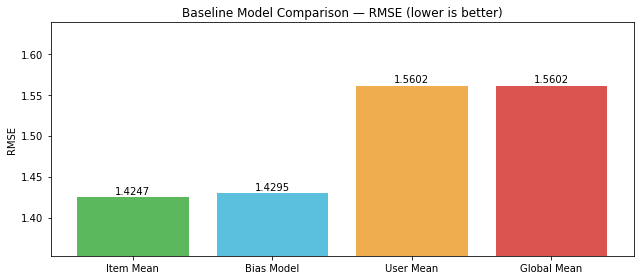

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#5cb85c', '#5bc0de', '#f0ad4e', '#d9534f']
bars = ax.bar(results['Model'], results['RMSE'], color=colors[:len(results)])
ax.set_title('Baseline Model Comparison — RMSE (lower is better)')
ax.set_ylabel('RMSE')
ax.set_ylim(results['RMSE'].min() * 0.95, results['RMSE'].max() * 1.05)
for bar, val in zip(bars, results['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/baseline_comparison.png', dpi=150)
plt.show()

## 7. What's Next

The bias model is our strongest baseline. It captures individual user tendencies and per-item quality signal — but it knows nothing about *taste*.

Two users who both rate action anime highly look identical to the bias model. The next step is collaborative filtering — learning latent factors that capture *what kind* of anime each user likes and matching them to *what kind* of anime each title is.

**Up next:** Matrix factorisation.